# CausalGym Controlled SVA Results

This notebook presents the controlled subject–verb agreement results for the BabyLM original + cloned-language GPT model. It only reads saved result files; it does not reload the checkpoint or rerun evaluation.

## 1. Locate the saved results

The notebook checks the local `output/` directory first and then the standard Google Drive run directory. Set `CAUSALGYM_SVA_DIR` if the files are somewhere else.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except ImportError:
    pass

manual_dir = os.environ.get("CAUSALGYM_SVA_DIR")
roots = [Path.cwd(), Path.cwd().parent, Path("/content/mllms-colab")]
candidates = []
if manual_dir:
    candidates.append(Path(manual_dir).expanduser())
for root in roots:
    candidates.append(root / "output/gpt12_babylm_clone_colab/causalgym_sva")
candidates.append(
    Path("/content/drive/MyDrive/mllms-colab/runs/")
    / "gpt12_babylm_clone_colab/causalgym_sva"
)

RESULTS_DIR = next(
    (path.resolve() for path in candidates if (path / "sva_summary.json").is_file()),
    None,
)
if RESULTS_DIR is None:
    searched = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        "Could not find sva_summary.json. Searched:\n" + searched
    )
print("Results directory:", RESULTS_DIR)

Results directory: /Users/jijiayi/Documents/25WS/MLLMs/project_chongzuo/mllms-colab/output/gpt12_babylm_clone_colab/causalgym_sva


In [2]:
summary = json.loads((RESULTS_DIR / "sva_summary.json").read_text())
metadata = json.loads((RESULTS_DIR / "sva_pairs.metadata.json").read_text())
records = [
    json.loads(line)
    for line in (RESULTS_DIR / "sva_results.jsonl").read_text().splitlines()
    if line.strip()
]
results = pd.json_normalize(records, sep=".")

snapshot = pd.DataFrame(
    {
        "value": [
            summary["checkpoint_step"],
            summary["overall"]["num_pairs"],
            2 * summary["overall"]["num_pairs"],
            metadata["clean_type_counts"]["singular"],
            metadata["clean_type_counts"]["plural"],
            summary["overall"]["joint_sanity_pairs"],
        ]
    },
    index=[
        "Checkpoint step",
        "Controlled pairs",
        "Evaluated prompts",
        "Clean singular pairs",
        "Clean plural pairs",
        "Joint sanity pairs",
    ],
)
display(snapshot)

,value
Checkpoint step,33116
Controlled pairs,900
Evaluated prompts,1800
Clean singular pairs,450
Clean plural pairs,450
Joint sanity pairs,65


## 2. Overall and task-level metrics

`accuracy` is measured over both prompts in every counterfactual pair. `pair_accuracy` requires the clean prompt and corrupted prompt to both prefer their correct number-inflected answer.

In [3]:
task_names = {
    "agr_sv_num_pp": "PP distractor",
    "agr_sv_num_obj-relc": "Object relative clause",
    "agr_sv_num_subj-relc": "Subject relative clause",
}
groups = [("Overall", summary["overall"])] + [
    (task_names.get(task, task), values)
    for task, values in summary["by_task"].items()
]
metric_rows = []
for group_name, values in groups:
    for language in ("original", "clone"):
        scores = values[language]
        metric_rows.append(
            {
                "group": group_name,
                "language": language.title(),
                "pairs": scores["num_pairs"],
                "accuracy": scores["accuracy"],
                "pair_accuracy": scores["pair_accuracy"],
                "clean_accuracy": scores["clean_accuracy"],
                "corrupted_accuracy": scores["corrupted_accuracy"],
                "mean_logit_difference": scores["mean_logit_difference"],
                "joint_sanity_pairs": values["joint_sanity_pairs"],
            }
        )
metrics = pd.DataFrame(metric_rows)
display(
    metrics.assign(
        accuracy=lambda frame: frame["accuracy"].map(lambda x: f"{x:.2%}"),
        pair_accuracy=lambda frame: frame["pair_accuracy"].map(lambda x: f"{x:.2%}"),
        clean_accuracy=lambda frame: frame["clean_accuracy"].map(lambda x: f"{x:.2%}"),
        corrupted_accuracy=lambda frame: frame["corrupted_accuracy"].map(lambda x: f"{x:.2%}"),
        mean_logit_difference=lambda frame: frame["mean_logit_difference"].map(lambda x: f"{x:+.3f}"),
    )
)

,group,language,pairs,accuracy,pair_accuracy,clean_accuracy,corrupted_accuracy,mean_logit_difference,joint_sanity_pairs
0,Overall,Original,900,57.22%,14.44%,56.56%,57.89%,+0.404,65
1,Overall,Clone,900,57.67%,15.56%,57.44%,57.89%,+0.452,65
2,Object relative clause,Original,302,54.47%,8.94%,53.31%,55.63%,+0.256,7
3,Object relative clause,Clone,302,54.97%,10.26%,55.96%,53.97%,+0.321,7
4,PP distractor,Original,296,65.03%,30.07%,64.86%,65.20%,+0.610,57
5,PP distractor,Clone,296,66.89%,34.12%,65.88%,67.91%,+0.670,57
6,Subject relative clause,Original,302,52.32%,4.64%,51.66%,52.98%,+0.351,1
7,Subject relative clause,Clone,302,51.32%,2.65%,50.66%,51.99%,+0.368,1


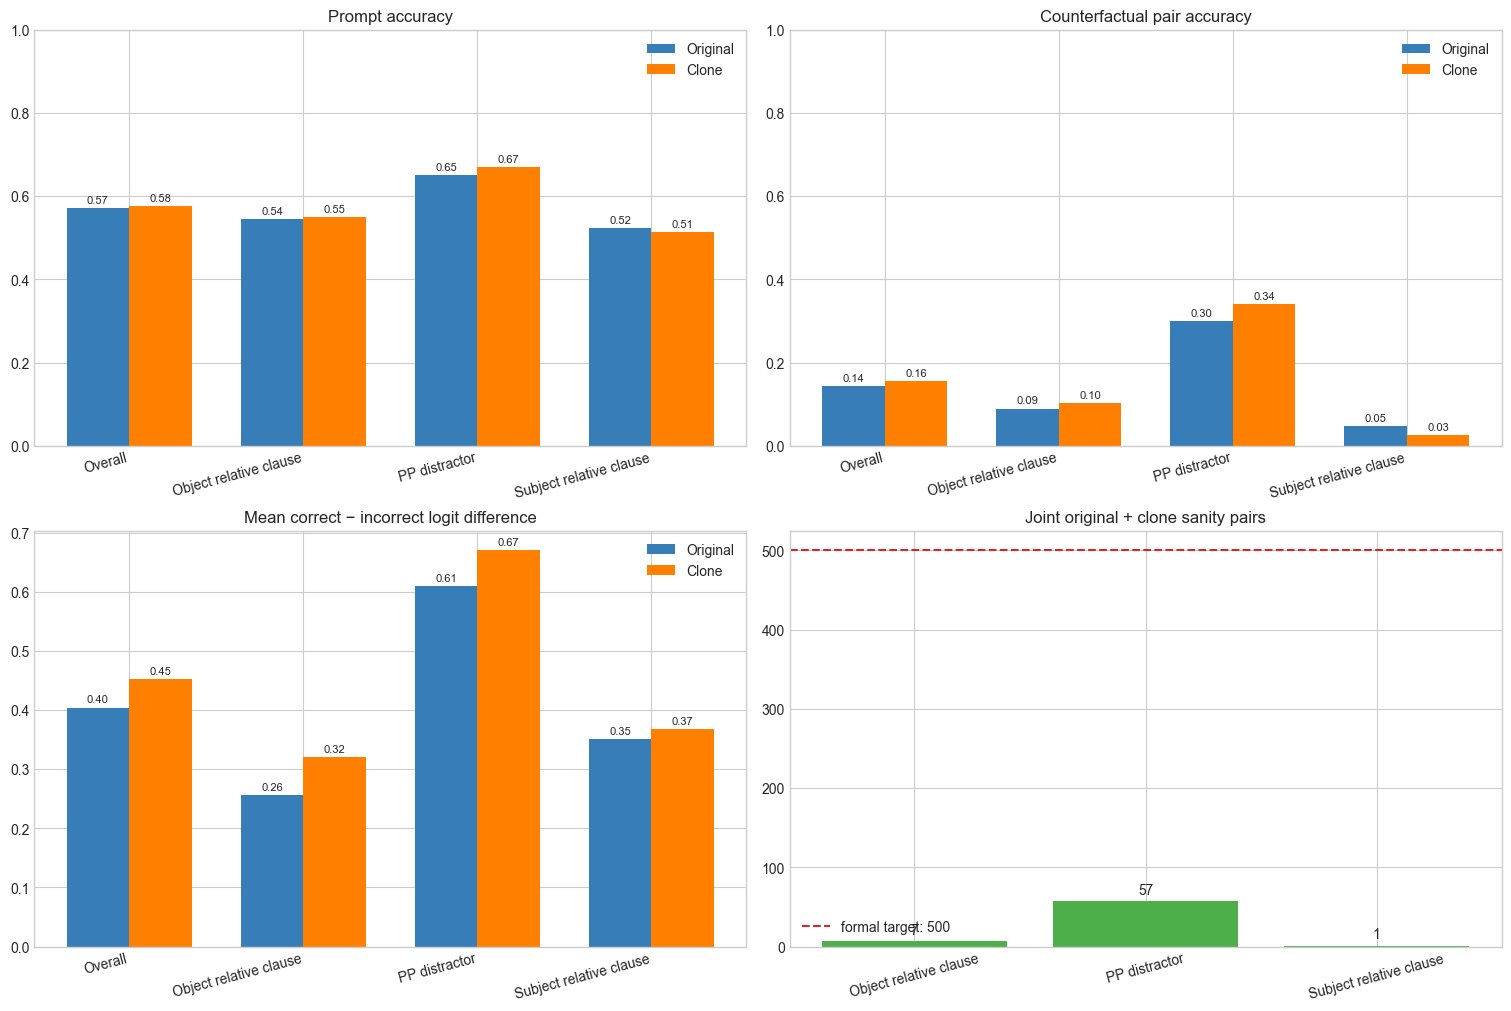

In [4]:
task_order = [name for name, _ in groups]
languages = ["Original", "Clone"]
colors = {"Original": "#377eb8", "Clone": "#ff7f00"}
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
plot_specs = [
    ("accuracy", "Prompt accuracy", (0, 1)),
    ("pair_accuracy", "Counterfactual pair accuracy", (0, 1)),
    ("mean_logit_difference", "Mean correct − incorrect logit difference", None),
]
x = range(len(task_order))
width = 0.36
for ax, (column, title, limits) in zip(axes.flat[:3], plot_specs):
    for offset, language in zip((-width / 2, width / 2), languages):
        subset = metrics[metrics["language"] == language].set_index("group").loc[task_order]
        positions = [index + offset for index in x]
        bars = ax.bar(positions, subset[column], width, label=language, color=colors[language])
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
    ax.set_title(title)
    ax.set_xticks(list(x), task_order, rotation=15, ha="right")
    if limits:
        ax.set_ylim(*limits)
    ax.legend()

sanity = pd.Series(
    {name: values["joint_sanity_pairs"] for name, values in groups[1:]},
    name="pairs",
)
bars = axes[1, 1].bar(sanity.index, sanity.values, color="#4daf4a")
axes[1, 1].bar_label(bars, padding=3)
axes[1, 1].axhline(500, color="#d62728", linestyle="--", label="formal target: 500")
axes[1, 1].set_title("Joint original + clone sanity pairs")
axes[1, 1].tick_params(axis="x", rotation=15)
axes[1, 1].legend()
plt.show()

## 3. Does the model flip its prediction?

A controlled pair changes the subject number. A structurally sensitive model should prefer one verb in the clean prompt and flip to the other verb in the corrupted prompt.

pattern,Both prompts correct,Both prompts wrong,Only clean correct,Only corrupted correct
language,,,,
Clone,140,2,377,381
Original,130,0,379,391


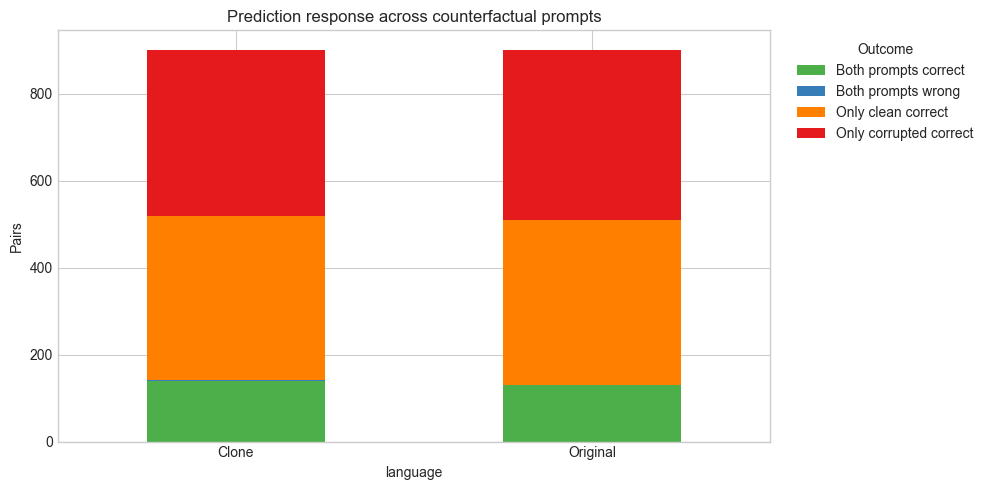

In [5]:
pattern_rows = []
for language in ("original", "clone"):
    clean = results[f"{language}.clean_correct"]
    corrupted = results[f"{language}.corrupted_correct"]
    labels = []
    for clean_ok, corrupted_ok in zip(clean, corrupted):
        if clean_ok and corrupted_ok:
            labels.append("Both prompts correct")
        elif clean_ok:
            labels.append("Only clean correct")
        elif corrupted_ok:
            labels.append("Only corrupted correct")
        else:
            labels.append("Both prompts wrong")
    counts = pd.Series(labels).value_counts()
    for label in ["Both prompts correct", "Only clean correct", "Only corrupted correct", "Both prompts wrong"]:
        pattern_rows.append(
            {"language": language.title(), "pattern": label, "pairs": int(counts.get(label, 0))}
        )
patterns = pd.DataFrame(pattern_rows)
pattern_table = patterns.pivot(index="language", columns="pattern", values="pairs").fillna(0).astype(int)
display(pattern_table)
ax = pattern_table.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#4daf4a", "#377eb8", "#ff7f00", "#e41a1c"])
ax.set_ylabel("Pairs")
ax.set_title("Prediction response across counterfactual prompts")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Original–clone correspondence

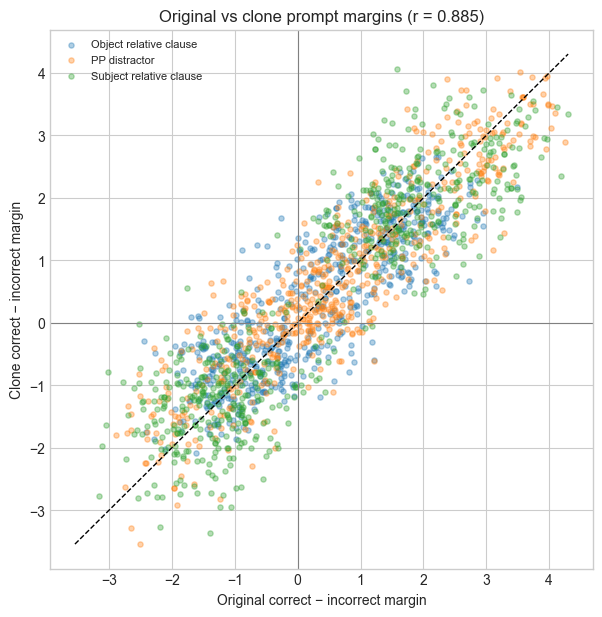

Pair prediction agreement: 82.11%


In [6]:
prompt_rows = []
for record in records:
    prompt_rows.extend(
        [
            {
                "task": task_names.get(record["task"], record["task"]),
                "prompt": "clean",
                "original_margin": record["original"]["clean_ld"],
                "clone_margin": record["clone"]["clean_ld"],
            },
            {
                "task": task_names.get(record["task"], record["task"]),
                "prompt": "corrupted",
                "original_margin": -record["original"]["corrupted_ld"],
                "clone_margin": -record["clone"]["corrupted_ld"],
            },
        ]
    )
prompt_scores = pd.DataFrame(prompt_rows)
correlation = prompt_scores[["original_margin", "clone_margin"]].corr().iloc[0, 1]
fig, ax = plt.subplots(figsize=(7, 7))
for task, group in prompt_scores.groupby("task"):
    ax.scatter(group["original_margin"], group["clone_margin"], s=14, alpha=0.35, label=task)
limits = [
    min(prompt_scores["original_margin"].min(), prompt_scores["clone_margin"].min()),
    max(prompt_scores["original_margin"].max(), prompt_scores["clone_margin"].max()),
]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Original correct − incorrect margin")
ax.set_ylabel("Clone correct − incorrect margin")
ax.set_title(f"Original vs clone prompt margins (r = {correlation:.3f})")
ax.legend(fontsize=8)
plt.show()
print(f"Pair prediction agreement: {summary['overall']['pair_prediction_agreement']:.2%}")

## 5. Hard examples and sanity-check subset

In [7]:
example_rows = []
for record in records:
    original_margins = [record["original"]["clean_ld"], -record["original"]["corrupted_ld"]]
    clone_margins = [record["clone"]["clean_ld"], -record["clone"]["corrupted_ld"]]
    example_rows.append(
        {
            "task": task_names.get(record["task"], record["task"]),
            "clean prompt": record["clean_prompt"],
            "corrupted prompt": record["corrupted_prompt"],
            "answers": f"{record['clean_answer']} / {record['corrupted_answer']}",
            "original min margin": min(original_margins),
            "clone min margin": min(clone_margins),
            "joint sanity": record["joint_sanity_pass"],
        }
    )
examples = pd.DataFrame(example_rows)
examples["joint min margin"] = examples[["original min margin", "clone min margin"]].min(axis=1)
print("Ten hardest subject-relative-clause pairs:")
display(
    examples[examples["task"] == "Subject relative clause"]
    .sort_values("joint min margin")
    .head(10)
    .drop(columns="joint min margin")
)

sanity_counts = (
    examples[examples["joint sanity"]]
    .groupby("task")
    .size()
    .rename("joint sanity pairs")
    .reindex(["PP distractor", "Object relative clause", "Subject relative clause"], fill_value=0)
)
display(sanity_counts.to_frame())

Ten hardest subject-relative-clause pairs:


,task,clean prompt,corrupted prompt,answers,original min margin,clone min margin,joint sanity
879,Subject relative clause,The authors that disguised the architects,The minister that disguised the architects,have / has,-1.394788,-3.361582,False
855,Subject relative clause,The farmer that disguised the author,The customers that disguised the author,has / have,-2.193751,-3.273766,False
526,Subject relative clause,The taxi driver that admired the secretary,The clerks that admired the secretary,is / are,-3.164876,-2.779851,False
541,Subject relative clause,The actor that disguised the secretary,The farmers that disguised the secretary,is / are,-3.113474,-1.973995,False
562,Subject relative clause,The doctors that admired the farmer,The doctor that admired the farmer,were / was,-3.042376,-1.631056,False
177,Subject relative clause,The authors that liked the senator,The customer that liked the senator,were / was,-3.020438,-0.786103,False
769,Subject relative clause,The officers that disguised the actors,The secretary that disguised the actors,were / was,-1.229720,-2.955621,False
620,Subject relative clause,The secretary that disguised the actors,The officers that disguised the actors,has / have,-1.066902,-2.944757,False
290,Subject relative clause,The guards that disguised the athlete,The customer that disguised the athlete,are / is,-2.538583,-2.807333,False
608,Subject relative clause,The actors that ignored the author,The secretary that ignored the author,have / has,-2.162073,-2.785987,False


,joint sanity pairs
task,
PP distractor,57
Object relative clause,7
Subject relative clause,1


## 6. Automatically generated conclusion

In [8]:
overall = summary["overall"]
original = overall["original"]
clone = overall["clone"]
joint = overall["joint_sanity_pairs"]
display(
    Markdown(
        f"""
### Main findings

- Original prompt accuracy: **{original['accuracy']:.2%}**; clone: **{clone['accuracy']:.2%}**.
- Original pair accuracy: **{original['pair_accuracy']:.2%}**; clone: **{clone['pair_accuracy']:.2%}**.
- The strongest task is the PP distractor; subject-relative clauses are approximately at chance.
- Only **{joint}** pairs pass the joint original + clone sanity check.
- This is enough for an exploratory patching run, but far below the planned 500-pair threshold for a formal activation-patching claim.
- Similar aggregate original/clone accuracy does not mean identical behavior: pair prediction agreement is **{overall['pair_prediction_agreement']:.2%}**.
"""
    )
)


### Main findings

- Original prompt accuracy: **57.22%**; clone: **57.67%**.
- Original pair accuracy: **14.44%**; clone: **15.56%**.
- The strongest task is the PP distractor; subject-relative clauses are approximately at chance.
- Only **65** pairs pass the joint original + clone sanity check.
- This is enough for an exploratory patching run, but far below the planned 500-pair threshold for a formal activation-patching claim.
- Similar aggregate original/clone accuracy does not mean identical behavior: pair prediction agreement is **82.11%**.


In [9]:
inventory = []
for path in sorted(RESULTS_DIR.iterdir()):
    if path.is_file():
        inventory.append({"file": path.name, "size_kib": round(path.stat().st_size / 1024, 1)})
display(pd.DataFrame(inventory))

,file,size_kib
0,sanity_pairs.jsonl,83.9
1,sva_pairs.jsonl,588.5
2,sva_pairs.metadata.json,0.9
3,sva_report.png,79.8
4,sva_results.jsonl,578.3
5,sva_summary.csv,1.1
6,sva_summary.json,4.6
